<a href="https://colab.research.google.com/github/Hmcg23/student_dropout_project/blob/main/ix_ds_project_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Student Dropout and Academic Success

Use student demographic, academic, and socioeconomic data to identify students at risk of dropping out, remaining enrolled, or succeeding academically.

**Project Question:** How can an institution identify students who may need support early enough to improve student outcomes?

[Project Dataset](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

**Models kept:** Random Forest and XGBoost (best performers). Other classifiers, PCA/t-SNE/UMAP, and the stacking ensemble were removed during cleanup.

**Focus of this version:** improve detection of the **Enrolled** class via consolidated feature engineering (before RFE), interaction features, and class-balancing techniques.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# For Kim:
import pandas as pd

# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/iX class project/dropout_data.csv', sep=';')
# display(df)

In [ ]:
# For Hudson:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data.csv', sep=';')
display(df)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [ ]:
# For Jacari:
import pandas as pd

# df = pd.read_csv('/content/dropout_data.csv', sep=';')
# display(df)

## Data Cleaning

The dataset creators performed rigorous preprocessing (anomalies, outliers, missing values), so little cleaning is needed. We confirm below.

In [ ]:
# Confirm no missing values and review distributions
display(df.isnull().sum())
display(df.describe())

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())
print("Numerical columns:", df.select_dtypes(include='number').columns.tolist())

Categorical columns: ['Target']
Numerical columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment ra

## Data Exploration

Correlation of each numerical feature with dropout status.

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


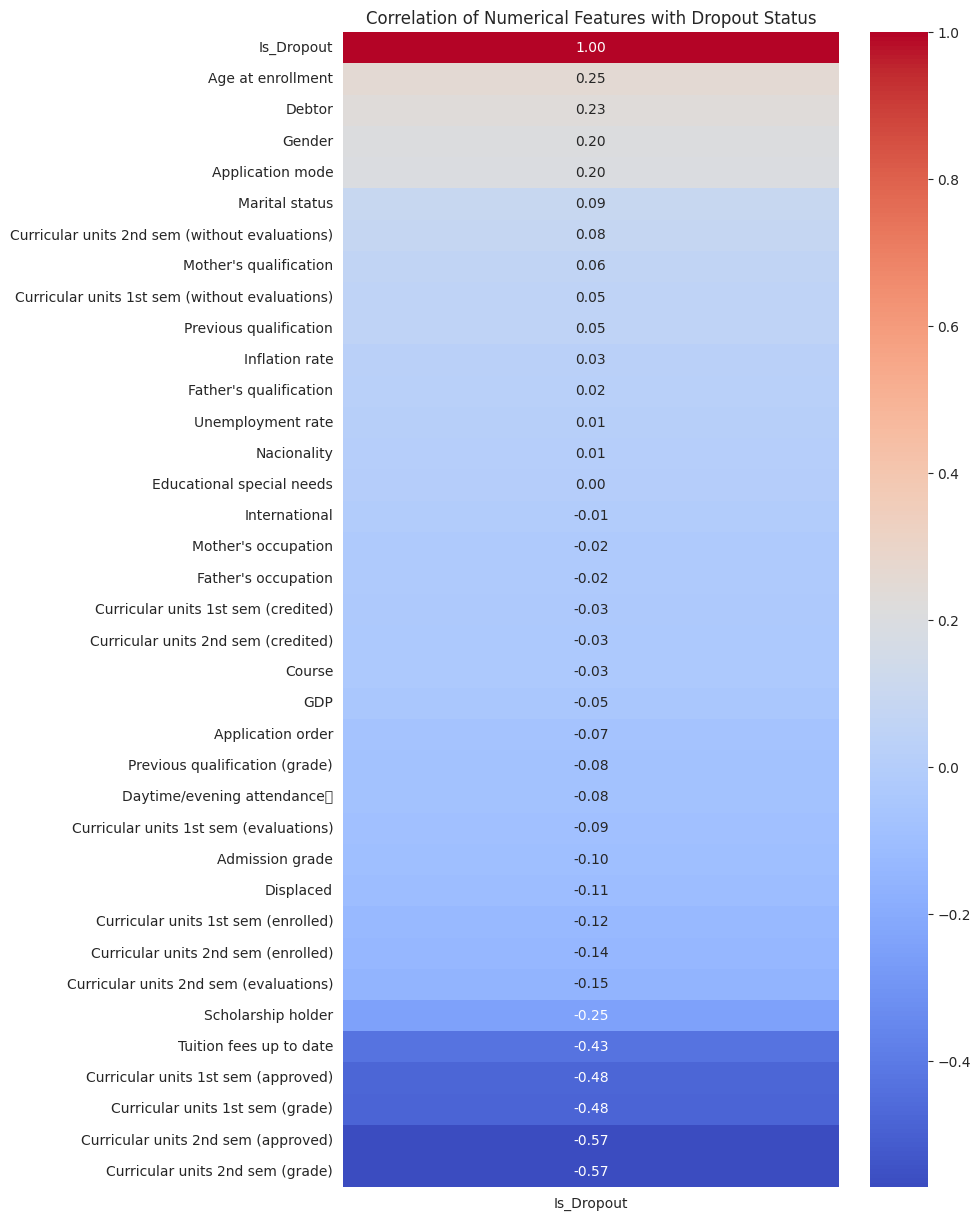

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Binary dropout flag for correlation analysis
df['Is_Dropout'] = (df['Target'] == 'Dropout').astype(int)

numerical_cols = df.select_dtypes(include='number').columns.tolist()
dropout_correlation = df[numerical_cols].corr()[['Is_Dropout']].sort_values(by='Is_Dropout', ascending=False)

plt.figure(figsize=(8, 15))
sns.heatmap(dropout_correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation of Numerical Features with Dropout Status')
plt.yticks(rotation=0)
plt.show()

## Class Balance Check

Confirm that **Enrolled** is the minority class — the root of the recall problem.

In [ ]:
print("Target counts:\n", df['Target'].value_counts())
print("\nTarget proportions:\n", df['Target'].value_counts(normalize=True).round(3))

Target counts:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target proportions:
 Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


## Feature Engineering (Round 1)

First-semester performance and financial-risk features.

In [ ]:
# 1. Approval rate (share of enrolled 1st-sem classes passed)
df["approval_rate_1st_sem"] = (
    df["Curricular units 1st sem (approved)"] /
    df["Curricular units 1st sem (enrolled)"]
).fillna(0)

# 2. Failed courses, 1st sem
df["failed_courses_1st_sem"] = (
    df["Curricular units 1st sem (enrolled)"] -
    df["Curricular units 1st sem (approved)"]
)

# 3. Average 1st-sem grade
df["avg_first_sem_grade"] = (
    df["Curricular units 1st sem (grade)"] /
    df["Curricular units 1st sem (approved)"]
).fillna(0)

# 4. Financial risk flag: debtor OR tuition not up to date
df["financial_risk"] = (
    (df["Debtor"] == 1) | (df["Tuition fees up to date"] == 0)
).astype(int)

new_features = ["approval_rate_1st_sem", "failed_courses_1st_sem", "avg_first_sem_grade", "financial_risk"]
print(df[new_features].head())

   approval_rate_1st_sem  failed_courses_1st_sem  avg_first_sem_grade  \
0               0.000000                       0             0.000000   
1               1.000000                       0             2.333333   
2               0.000000                       6             0.000000   
3               1.000000                       0             2.238095   
4               0.833333                       1             2.466667   

   financial_risk  
0               0  
1               1  
2               1  
3               0  
4               0  


## Data Encoding and Final Cleaning

Drop redundant columns and map the `Target` to numbers (Dropout=0, Enrolled=1, Graduate=2).

In [ ]:
# Drop low-value columns and the EDA-only Is_Dropout flag
columns_to_drop = ['Application mode', 'Nacionality', 'Application order', 'Is_Dropout']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df_prepared = df.drop(columns=existing_cols_to_drop)

target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_prepared['Target'] = df_prepared['Target'].map(target_mapping)

print("Columns removed:", existing_cols_to_drop)
print("Target distribution:\n", df_prepared['Target'].value_counts())
display(df_prepared.head())

Columns removed: ['Application mode', 'Nacionality', 'Application order', 'Is_Dropout']
Target distribution:
 Target
2    2209
0    1421
1     794
Name: count, dtype: int64


,Marital status,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,approval_rate_1st_sem,failed_courses_1st_sem,avg_first_sem_grade,financial_risk
0,1,171,1,1,122.0,19,12,5,9,127.3,...,0.000000,0,10.8,1.4,1.74,0,0.000000,0,0.000000,0
1,1,9254,1,1,160.0,1,3,3,3,142.5,...,13.666667,0,13.9,-0.3,0.79,2,1.000000,0,2.333333,1
2,1,9070,1,1,122.0,37,37,9,9,124.8,...,0.000000,0,10.8,1.4,1.74,0,0.000000,6,0.000000,1
3,1,9773,1,1,122.0,38,37,5,3,119.6,...,12.400000,0,9.4,-0.8,-3.12,2,1.000000,0,2.238095,0
4,2,8014,0,1,100.0,37,38,9,9,141.5,...,13.000000,0,13.9,-0.3,0.79,2,0.833333,1,2.466667,0


## Feature Engineering (Round 2): Trends, Overall Success, and Interactions

All engineered features are created **here, before RFE**, so feature selection can see them.
This fixes the earlier ordering issue where features were added after RFE had already run.

Includes cross-semester trends, overall-success metrics, and **interaction features** aimed
at the ambiguous Enrolled class (students who are mid-trajectory rather than clearly
succeeding or failing).

In [ ]:
# --- Cross-semester trend & overall-success features ---
df_prepared["approved_units_diff"] = (
    df_prepared["Curricular units 2nd sem (approved)"] - df_prepared["Curricular units 1st sem (approved)"]
)

total_enrolled = df_prepared["Curricular units 1st sem (enrolled)"] + df_prepared["Curricular units 2nd sem (enrolled)"]
total_approved = df_prepared["Curricular units 1st sem (approved)"] + df_prepared["Curricular units 2nd sem (approved)"]
df_prepared["overall_approval_rate"] = (total_approved / total_enrolled).fillna(0)

sum_grades_1st = df_prepared["avg_first_sem_grade"] * df_prepared["Curricular units 1st sem (approved)"]
sum_grades_2nd = df_prepared["Curricular units 2nd sem (grade)"] * df_prepared["Curricular units 2nd sem (approved)"]
df_prepared["overall_grade_avg"] = ((sum_grades_1st + sum_grades_2nd) / total_approved).fillna(0)

df_prepared["second_sem_pass_rate"] = (
    df_prepared["Curricular units 2nd sem (approved)"] / df_prepared["Curricular units 2nd sem (enrolled)"]
).fillna(0)

df_prepared["grade_improvement"] = (
    df_prepared["Curricular units 2nd sem (grade)"] - df_prepared["Curricular units 1st sem (grade)"]
).fillna(0)

df_prepared["failures_2nd_sem"] = (
    df_prepared["Curricular units 2nd sem (enrolled)"] - df_prepared["Curricular units 2nd sem (approved)"]
)

df_prepared["missed_eval_ratio_1st"] = (
    df_prepared["Curricular units 1st sem (without evaluations)"] / df_prepared["Curricular units 1st sem (enrolled)"]
).fillna(0)

df_prepared["missed_eval_ratio_2nd"] = (
    df_prepared["Curricular units 2nd sem (without evaluations)"] / df_prepared["Curricular units 2nd sem (enrolled)"]
).fillna(0)

df_prepared["financial_risk_score"] = df_prepared["Debtor"] + (1 - df_prepared["Tuition fees up to date"])

df_prepared["parent_education_avg"] = (
    (df_prepared["Mother's qualification"] + df_prepared["Father's qualification"]) / 2
).fillna(0)

# --- Interaction features (target the ambiguous Enrolled class) ---
# Compounding academic risk: failing courses AND a low pass rate
df_prepared["academic_risk"] = (
    df_prepared["failed_courses_1st_sem"] * (1 - df_prepared["approval_rate_1st_sem"])
)

# Financial stress compounded with academic struggle
df_prepared["financial_academic_risk"] = (
    df_prepared["financial_risk_score"] * df_prepared["failed_courses_1st_sem"]
)

# Grade volatility between semesters (mid-trajectory students swing more)
df_prepared["grade_consistency"] = (
    df_prepared["Curricular units 2nd sem (grade)"] - df_prepared["Curricular units 1st sem (grade)"]
).abs()

engineered = [
    "approved_units_diff", "overall_approval_rate", "overall_grade_avg", "second_sem_pass_rate",
    "grade_improvement", "failures_2nd_sem", "missed_eval_ratio_1st", "missed_eval_ratio_2nd",
    "financial_risk_score", "parent_education_avg",
    "academic_risk", "financial_academic_risk", "grade_consistency",
]
print("Engineered feature count:", len(engineered))
display(df_prepared[engineered].head())

Engineered feature count: 13


,approved_units_diff,overall_approval_rate,overall_grade_avg,second_sem_pass_rate,grade_improvement,failures_2nd_sem,missed_eval_ratio_1st,missed_eval_ratio_2nd,financial_risk_score,parent_education_avg,academic_risk,financial_academic_risk,grade_consistency
0,0,0.000000,0.000000,0.000000,0.000000,0,0.0,0.0,0,15.5,0.000000,0,0.000000
1,0,1.000000,8.000000,1.000000,-0.333333,0,0.0,0.0,1,2.0,0.000000,0,0.333333
2,0,0.000000,0.000000,0.000000,0.000000,6,0.0,0.0,1,37.0,6.000000,6,0.000000
3,-1,0.916667,6.857143,0.833333,-1.028571,1,0.0,0.0,0,37.5,0.000000,0,1.028571
4,1,0.916667,8.212121,1.000000,0.666667,0,0.0,0.0,0,37.5,0.166667,0,0.666667


## Feature Scaling

Standardize features with `StandardScaler` (needed for clustering).

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_prepared.drop(columns=['Target'])
y = df_prepared['Target']

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("Scaled feature shape:", df_scaled.shape)
display(df_scaled.head())

Scaled feature shape: (4424, 50)


,Marital status,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,...,second_sem_pass_rate,grade_improvement,failures_2nd_sem,missed_eval_ratio_1st,missed_eval_ratio_2nd,financial_risk_score,parent_education_avg,academic_risk,financial_academic_risk,grade_consistency
0,-0.294829,-4.209520,0.350082,-0.35023,-0.804841,-0.036018,-0.669778,-0.225661,-0.080456,0.022229,...,-1.724524,0.142079,-0.837689,-0.210624,-0.200255,-0.432796,-0.399757,-0.556502,-0.320544,-0.478721
1,-0.294829,0.192580,0.350082,-0.35023,2.076819,-1.189759,-1.256427,-0.301375,-0.317984,1.071926,...,0.886982,0.026741,-0.837689,-0.210624,-0.200255,1.424324,-1.395714,-0.556502,-0.320544,-0.352119
2,-0.294829,0.103404,0.350082,-0.35023,-0.804841,1.117723,0.959802,-0.074233,-0.080456,-0.150419,...,-1.724524,0.142079,1.960300,-0.210624,-0.200255,1.424324,1.186397,2.606732,2.621546,-0.478721
3,-0.294829,0.444115,0.350082,-0.35023,-0.804841,1.181819,0.959802,-0.225661,-0.317984,-0.509526,...,0.451731,-0.213822,-0.371358,-0.210624,-0.200255,-0.432796,1.223284,-0.556502,-0.320544,-0.088063
4,1.356212,-0.408389,-2.856470,-0.35023,-2.473171,1.117723,1.024985,-0.074233,-0.080456,1.002867,...,0.886982,0.372756,-0.837689,-0.210624,-0.200255,-0.432796,1.223284,-0.468635,-0.320544,-0.225517


## K-Means Clustering (Feature Creation)

Group students by similarity and add the cluster label as a synthetic feature that captures non-linear structure.

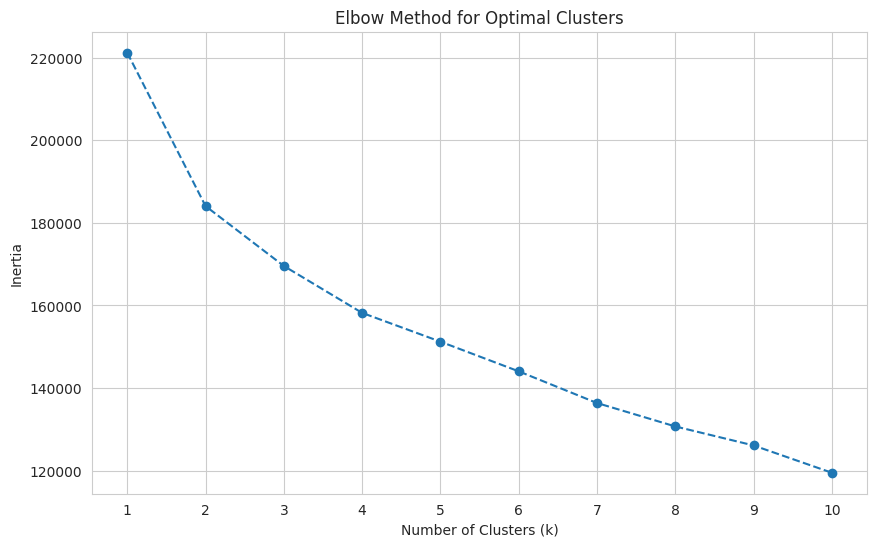

In [ ]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
# k=5 chosen from elbow plot + project context
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_prepared['Cluster'] = kmeans.fit_predict(df_scaled)

print(f'Added Cluster feature with {k_optimal} clusters.')
print(df_prepared['Cluster'].value_counts())

Added Cluster feature with 5 clusters.
Cluster
3    3045
4     506
2     392
1     273
0     208
Name: count, dtype: int64


## Recursive Feature Elimination (RFE)

Single RFECV pass with an XGBoost estimator over the **full** feature set (originals +
all engineered + interaction + cluster), so selection reflects every feature.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Optimal number of features: 43
Selected features: ['Course', 'Daytime/evening attendance\t', 'Previous qualification (grade)', "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'approval_rate_1st_sem', 'failed_courses_1st_sem', 'avg_first_sem_grade', 'financial_risk', 'approved_units_diff', 'overall_approval_rate', 'overall_grad

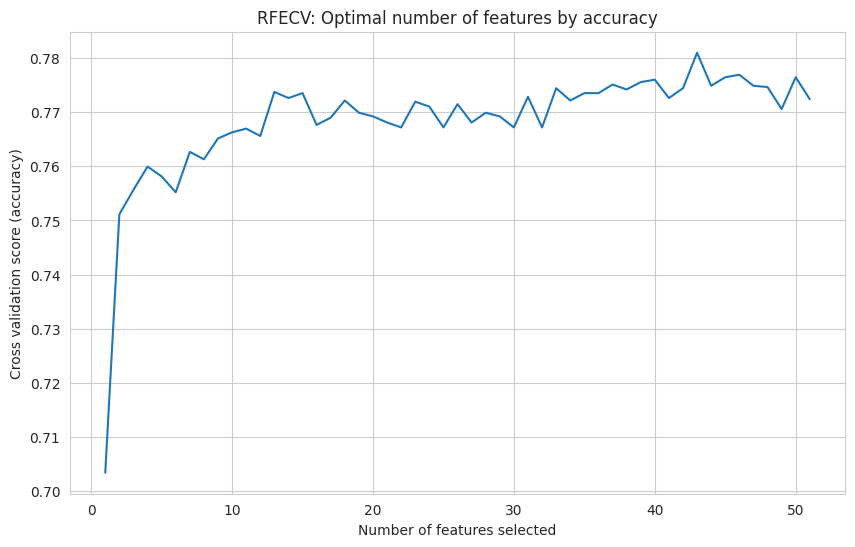

Shape after RFE: (4424, 43)


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

X = df_prepared.drop(columns=['Target'])
y = df_prepared['Target']

estimator = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    min_features_to_select=1,
    n_jobs=-1
)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")
selected_features = X.columns[rfecv.support_]
print("Selected features:", selected_features.tolist())

# Highlight which engineered/interaction features survived selection
kept_engineered = [f for f in selected_features if f in engineered]
print("\nEngineered features kept by RFE:", kept_engineered)

plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.title('RFECV: Optimal number of features by accuracy')
plt.grid(True)
plt.show()

X_rfe = X[selected_features].copy()
print("Shape after RFE:", X_rfe.shape)

## Train-Test Split

Single stratified 80/20 split to preserve class balance.

In [ ]:
from sklearn.model_selection import train_test_split

X_final = X_rfe
y_final = y

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (3539, 43), X_test: (885, 43)


## Model Training: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.7740112994350282

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78       284
           1       0.57      0.38      0.46       159
           2       0.80      0.92      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



## Model Training: XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_train.unique()),
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance:
Accuracy: 0.7627118644067796

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77       284
           1       0.52      0.41      0.46       159
           2       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.69       885
weighted avg       0.75      0.76      0.75       885



## Model Comparison: Random Forest vs XGBoost

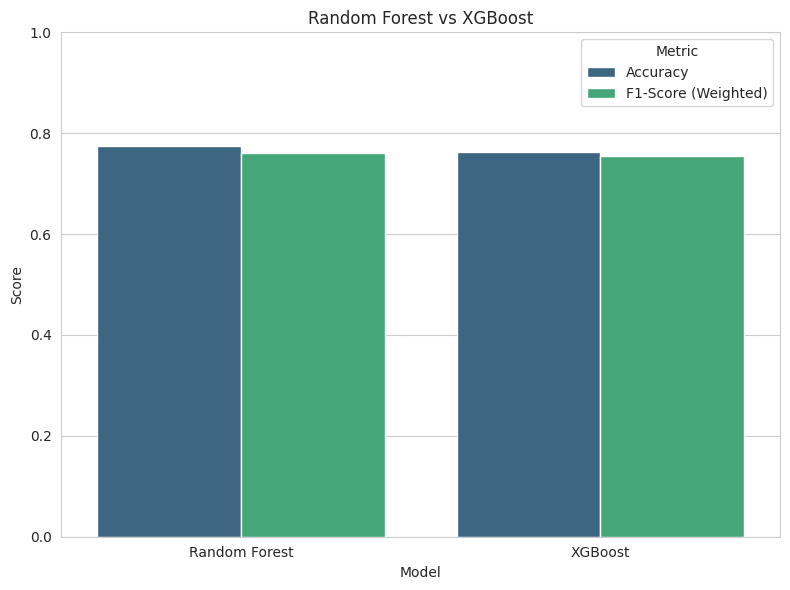

,Model,Accuracy,F1-Score (Weighted)
0,Random Forest,0.774011,0.761732
1,XGBoost,0.762712,0.754604


In [ ]:
from sklearn.metrics import f1_score

model_predictions = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
}

model_performance = []
for name, preds in model_predictions.items():
    model_performance.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1-Score (Weighted)': f1_score(y_test, preds, average='weighted')
    })

performance_df = pd.DataFrame(model_performance)
performance_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_melted, palette='viridis')
plt.title('Random Forest vs XGBoost')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

display(performance_df.sort_values(by='Accuracy', ascending=False))

## Model Evaluation: ROC Curves and AUC

One-vs-rest ROC curves for Random Forest and XGBoost across the three classes.

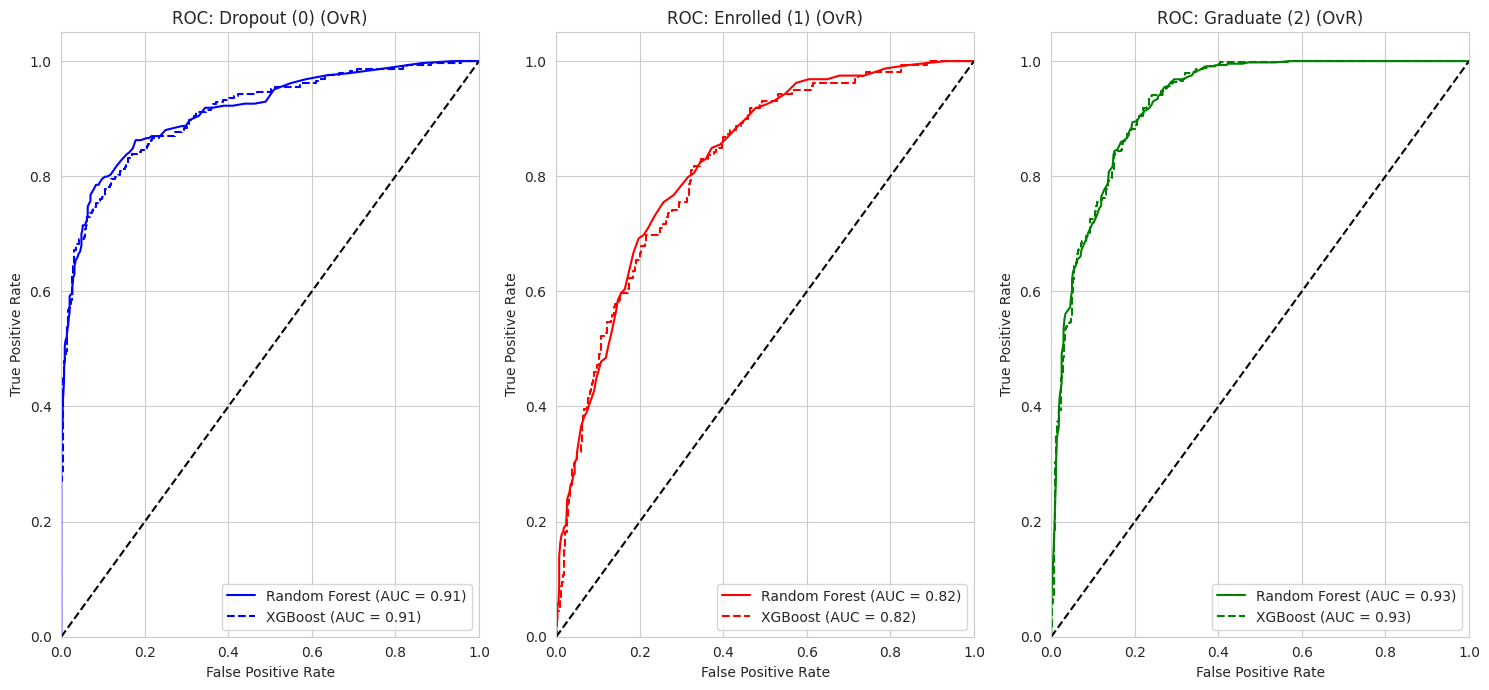

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_proba_rf = rf_model.predict_proba(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]

model_probs = {'Random Forest': y_pred_proba_rf, 'XGBoost': y_pred_proba_xgb}
roc_data = {name: {'fpr': {}, 'tpr': {}, 'auc': {}} for name in model_probs}

for name, proba in model_probs.items():
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], proba[:, i])
        roc_data[name]['fpr'][i] = fpr
        roc_data[name]['tpr'][i] = tpr
        roc_data[name]['auc'][i] = auc(fpr, tpr)

class_labels = ['Dropout (0)', 'Enrolled (1)', 'Graduate (2)']
colors = ['blue', 'red', 'green']
linestyles = ['-', '--']

plt.figure(figsize=(15, 7))
for i in range(n_classes):
    plt.subplot(1, n_classes, i + 1)
    for j, (name, data) in enumerate(roc_data.items()):
        plt.plot(data['fpr'][i], data['tpr'][i], color=colors[i], linestyle=linestyles[j],
                 label=f'{name} (AUC = {data["auc"][i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC: {class_labels[i]} (OvR)')
    plt.legend(loc='lower right'); plt.grid(True)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning: Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
import time

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [42]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=2
)

print("Tuning Random Forest...")
start = time.time()
grid_search_rf.fit(X_train, y_train)
print(f"Done in {time.time() - start:.2f}s.")

best_params_rf = grid_search_rf.best_params_
print(f"\nBest params: {best_params_rf}")
print(f"Best CV accuracy: {grid_search_rf.best_score_:.4f}")

Tuning Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Done in 256.97s.

Best params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200, 'random_state': 42}
Best CV accuracy: 0.7776


In [ ]:
tuned_rf_model = RandomForestClassifier(**best_params_rf)
tuned_rf_model.fit(X_train, y_train)
y_pred_tuned_rf = tuned_rf_model.predict(X_test)

print("Tuned Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned_rf))

Tuned Random Forest Performance:
Accuracy: 0.7728813559322034

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78       284
           1       0.57      0.38      0.45       159
           2       0.80      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



## Hyperparameter Tuning: XGBoost

In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'random_state': [42]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softmax',
        num_class=len(y_train.unique()),
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid_xgb,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=2
)

print("Tuning XGBoost...")
start = time.time()
grid_search_xgb.fit(X_train, y_train)
print(f"Done in {time.time() - start:.2f}s.")

best_params_xgb = grid_search_xgb.best_params_
print(f"\nBest params: {best_params_xgb}")
print(f"Best CV accuracy: {grid_search_xgb.best_score_:.4f}")

Tuning XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:00:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done in 688.01s.

Best params: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'subsample': 1.0}
Best CV accuracy: 0.7813


In [ ]:
tuned_xgb_model = XGBClassifier(**best_params_xgb)
tuned_xgb_model.fit(X_train, y_train)
y_pred_tuned_xgb = tuned_xgb_model.predict(X_test)

print("Tuned XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned_xgb))

Tuned XGBoost Performance:
Accuracy: 0.7706214689265537

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77       284
           1       0.54      0.40      0.46       159
           2       0.81      0.92      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



# Improving Enrolled-Class Detection

The Enrolled class (1) is the minority and the hardest to classify. Below we test
class-balancing strategies and rank models by **macro-F1 and Enrolled recall/F1**,
not just overall accuracy — a model that catches more at-risk/in-progress students is
more useful for early intervention even if total accuracy dips slightly.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Helper: score a model's predictions with Enrolled-focused metrics
def score_model(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'Enrolled Recall': report['1']['recall'],
        'Enrolled F1': report['1']['f1-score'],
    }

results = []
results.append(score_model("RF (baseline)", y_test, y_pred_rf))
results.append(score_model("RF (tuned)", y_test, y_pred_tuned_rf))
results.append(score_model("XGBoost (tuned)", y_test, y_pred_tuned_xgb))
print("Baselines scored.")

Baselines scored.


### 1. Random Forest + `class_weight='balanced'`

Reweights classes inversely to frequency so the minority Enrolled class counts more.

In [ ]:
# Reuse tuned RF params, add balanced class weights
rf_balanced = RandomForestClassifier(**{**best_params_rf, 'class_weight': 'balanced'})
rf_balanced.fit(X_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(X_test)

print("RF (balanced) Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_balanced))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_balanced, zero_division=0))

results.append(score_model("RF (class_weight)", y_test, y_pred_rf_balanced))

RF (balanced) Performance:
Accuracy: 0.7649717514124293

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       284
           1       0.50      0.50      0.50       159
           2       0.83      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.76      0.76      0.76       885



### 2. Random Forest + SMOTE

Synthetically oversample the Enrolled class **in the training set only** (no test leakage),
then retrain the tuned Random Forest.

In [ ]:
import sys
!{sys.executable} -m pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Class balance after SMOTE:\n", pd.Series(y_train_smote).value_counts())

Class balance after SMOTE:
 Target
2    1767
0    1767
1    1767
Name: count, dtype: int64


In [ ]:
rf_smote = RandomForestClassifier(**{**best_params_rf, 'class_weight': 'balanced'})
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

print("RF (SMOTE) Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_smote, zero_division=0))

results.append(score_model("RF (SMOTE)", y_test, y_pred_rf_smote))

RF (SMOTE) Performance:
Accuracy: 0.768361581920904

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.52      0.50      0.51       159
           2       0.82      0.88      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



### 3. Tuned XGBoost + class weights

XGBoost has no `class_weight`; instead we pass balanced **per-sample** weights computed
from the training labels.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_balanced = XGBClassifier(**best_params_xgb)
xgb_balanced.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb_balanced = xgb_balanced.predict(X_test)

print("XGBoost (balanced) Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_balanced))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_balanced, zero_division=0))

results.append(score_model("XGBoost (sample_weight)", y_test, y_pred_xgb_balanced))

XGBoost (balanced) Performance:
Accuracy: 0.7423728813559322

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.70      0.76       284
           1       0.45      0.66      0.53       159
           2       0.86      0.80      0.83       442

    accuracy                           0.74       885
   macro avg       0.71      0.72      0.71       885
weighted avg       0.78      0.74      0.75       885



### Comparison: Which model best detects Enrolled students?

Ranked by **macro-F1 then Enrolled recall**. The baseline maximizes accuracy; the balanced
variants trade a little accuracy for substantially better Enrolled detection.

,Model,Accuracy,Macro F1,Enrolled Recall,Enrolled F1
0,RF (SMOTE),0.768,0.714,0.503,0.510
1,RF (class_weight),0.765,0.709,0.503,0.502
2,XGBoost (sample_weight),0.742,0.707,0.660,0.534
3,RF (baseline),0.774,0.700,0.384,0.459
4,RF (tuned),0.773,0.698,0.377,0.455
5,XGBoost (tuned),0.771,0.697,0.396,0.457


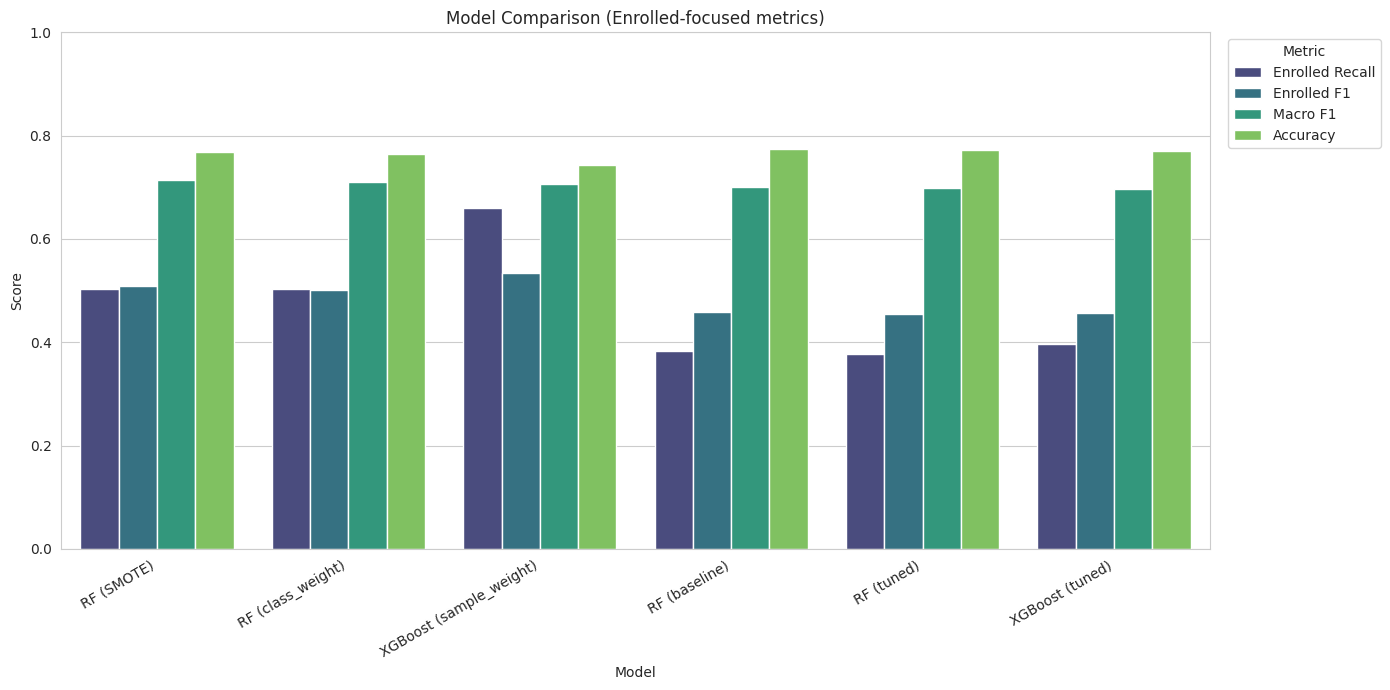

In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by=['Macro F1', 'Enrolled Recall'], ascending=False
).reset_index(drop=True)
display(results_df.round(3))

# Visualize the Enrolled-focused metrics
plot_df = results_df.melt(
    id_vars='Model',
    value_vars=['Enrolled Recall', 'Enrolled F1', 'Macro F1', 'Accuracy'],
    var_name='Metric', value_name='Score'
)
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')
plt.title('Model Comparison (Enrolled-focused metrics)')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Select the best model by macro-F1 then Enrolled recall
best_row = results_df.iloc[0]
best_name = best_row['Model']

prediction_lookup = {
    "RF (baseline)": (rf_model, y_pred_rf),
    "RF (tuned)": (tuned_rf_model, y_pred_tuned_rf),
    "XGBoost (tuned)": (tuned_xgb_model, y_pred_tuned_xgb),
    "RF (class_weight)": (rf_balanced, y_pred_rf_balanced),
    "RF (SMOTE)": (rf_smote, y_pred_rf_smote),
    "XGBoost (sample_weight)": (xgb_balanced, y_pred_xgb_balanced),
}
best_model, y_pred_best = prediction_lookup[best_name]

print(f"Best model by macro-F1 + Enrolled recall: {best_name}")
print(best_row.round(3).to_string())

Best model by macro-F1 + Enrolled recall: RF (SMOTE)
Model              RF (SMOTE)
Accuracy             0.768362
Macro F1             0.713776
Enrolled Recall      0.503145
Enrolled F1          0.509554


## Feature Importance (Random Forest)

Confirms whether the engineered/interaction features rose into the top predictors.

/tmp/ipykernel_9622/1671778547.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


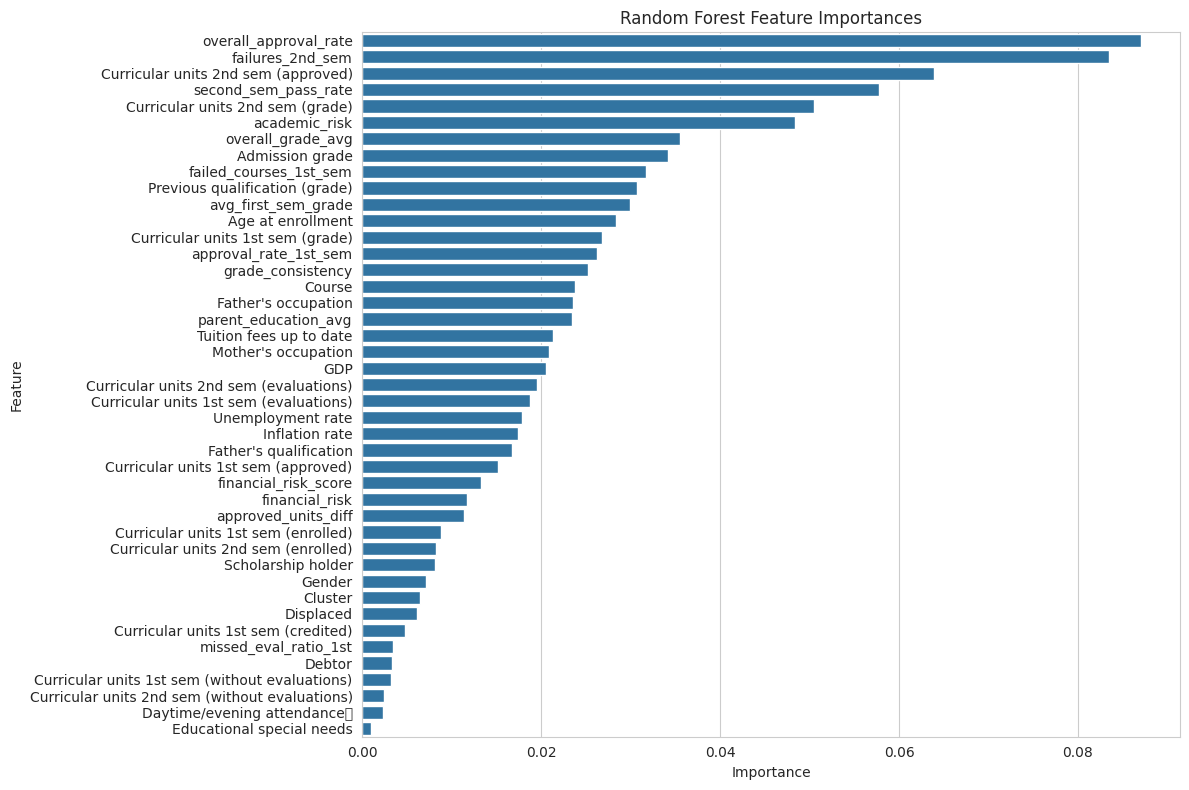

Top 10 features:


,Feature,Importance
33,overall_approval_rate,0.087054
36,failures_2nd_sem,0.083460
22,Curricular units 2nd sem (approved),0.063894
35,second_sem_pass_rate,0.057715
23,Curricular units 2nd sem (grade),0.050472
40,academic_risk,0.048314
34,overall_grade_avg,0.035544
6,Admission grade,0.034120
29,failed_courses_1st_sem,0.031722
2,Previous qualification (grade),0.030724


In [ ]:
feature_importances = rf_model.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

print("Top 10 features:")
display(features_df.head(10))

### Top 5 Most Important Features Influencing Dropout

/tmp/ipykernel_9622/1462736361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis')


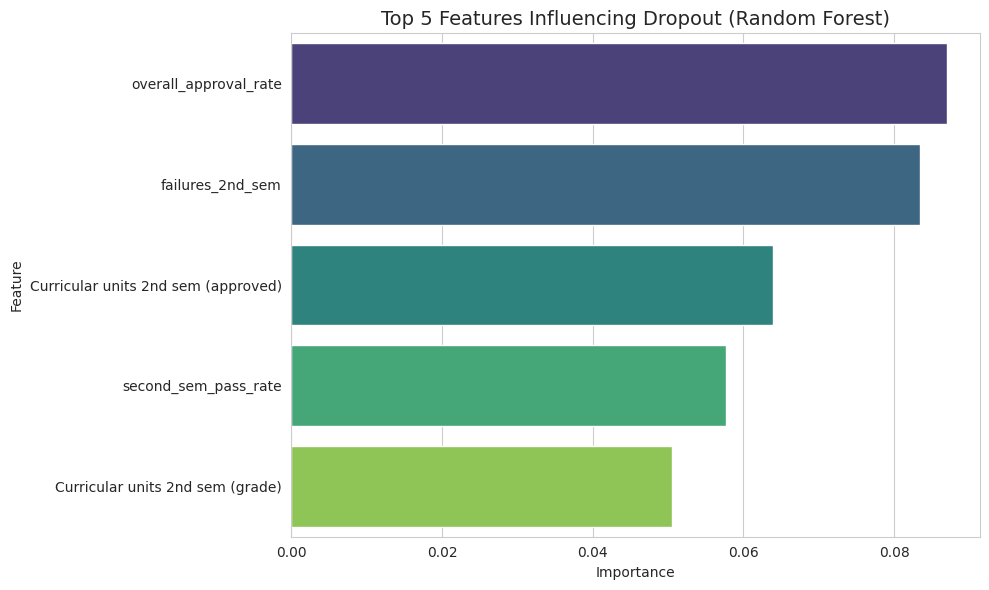

,Feature,Importance
33,overall_approval_rate,0.087054
36,failures_2nd_sem,0.083460
22,Curricular units 2nd sem (approved),0.063894
35,second_sem_pass_rate,0.057715
23,Curricular units 2nd sem (grade),0.050472


In [ ]:
top_5_features = features_df.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis')
plt.title('Top 5 Features Influencing Dropout (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

display(top_5_features)

## Confusion Matrix: Best Model

Compare the baseline RF confusion matrix with the selected best model — watch the
**Enrolled (row 1)** correct count improve.

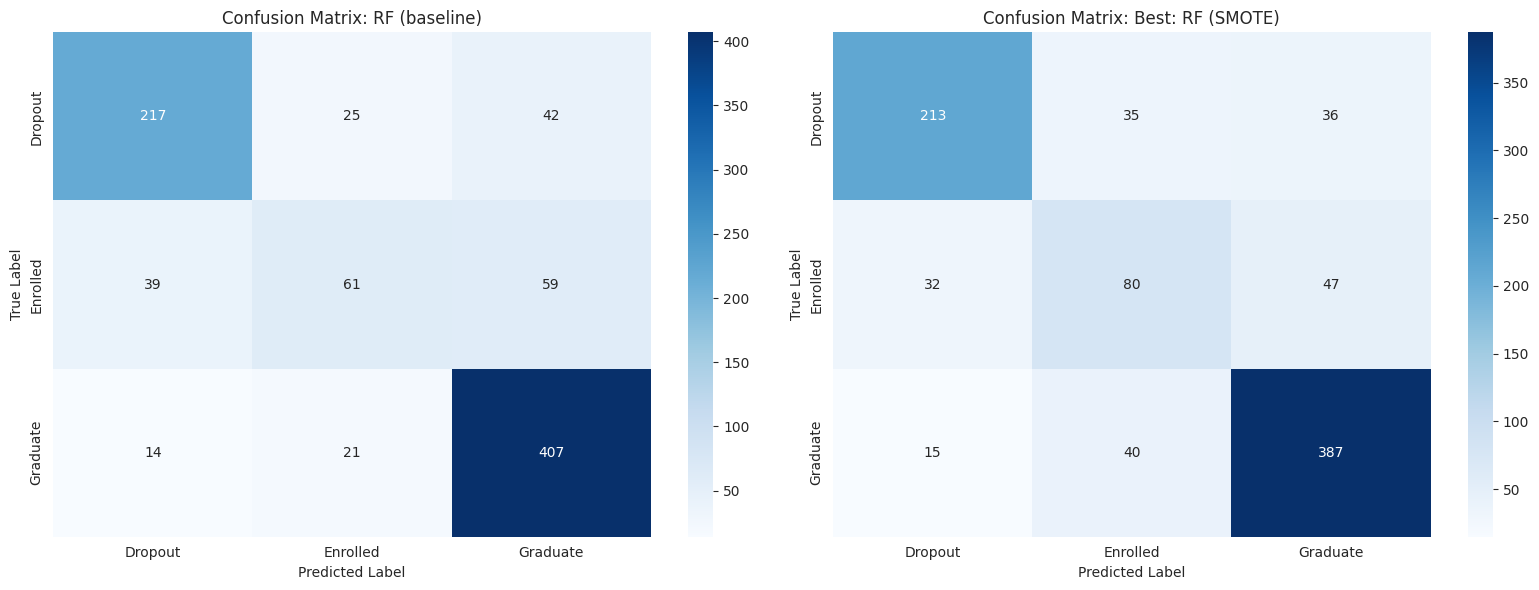

In [ ]:
from sklearn.metrics import confusion_matrix

class_names_cm = ['Dropout', 'Enrolled', 'Graduate']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, preds) in zip(axes, [("RF (baseline)", y_pred_rf), (f"Best: {best_name}", y_pred_best)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_cm, yticklabels=class_names_cm, ax=ax)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Interpret Predictions with SHAP

Use SHAP to explain individual student predictions and per-class feature impact for the tuned Random Forest.

In [ ]:
import sys
!{sys.executable} -m pip install shap
import shap

# TreeExplainer on the tuned Random Forest
explainer = shap.TreeExplainer(tuned_rf_model, feature_names=X_train.columns)
print("SHAP explainer initialized.")

SHAP explainer initialized.


In [ ]:
# Sample a few students to explain individually
sample_X_test = X_test.sample(n=5, random_state=42)
shap_values = explainer.shap_values(sample_X_test)
print(f"Computed SHAP values for {sample_X_test.shape[0]} students.")
display(sample_X_test.head())

Computed SHAP values for 5 students.


,Course,Daytime/evening attendance\t,Previous qualification (grade),Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,...,overall_approval_rate,overall_grade_avg,second_sem_pass_rate,failures_2nd_sem,missed_eval_ratio_1st,financial_risk_score,parent_education_avg,academic_risk,grade_consistency,Cluster
2873,9254,1,120.0,37,4,9,120.0,0,0,0,...,0.866667,6.680473,0.866667,2,0.0,0,37.0,0.266667,0.307692,1
891,171,1,147.0,38,175,193,133.3,0,0,0,...,0.000000,0.000000,0.000000,0,0.0,1,37.5,0.000000,0.000000,4
3799,9085,1,133.1,39,5,3,140.0,1,0,1,...,0.000000,0.000000,0.000000,6,0.0,2,20.0,6.000000,0.000000,2
1250,9254,1,158.0,39,4,8,153.5,1,0,0,...,1.000000,9.236111,1.000000,0,0.0,0,29.0,0.000000,1.166667,3
555,9003,1,150.0,2,2,2,150.0,0,0,0,...,0.869565,3.878571,0.666667,3,0.0,0,2.5,0.000000,1.571429,1


Student 2873 predicted as 'Graduate'


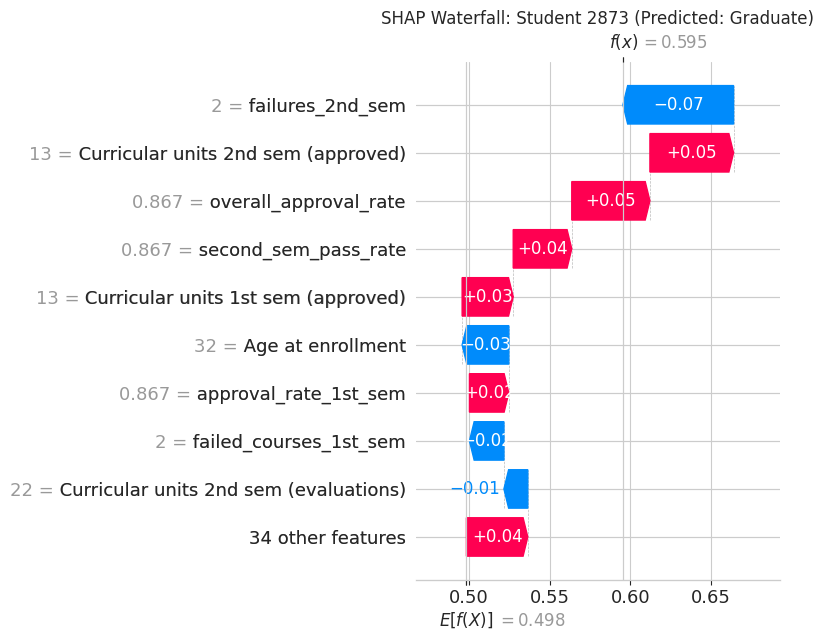

In [ ]:
# Waterfall plot for one student's predicted class
class_names = ['Dropout', 'Enrolled', 'Graduate']
instance_idx = 0
sample_instance = sample_X_test.iloc[[instance_idx]]
predicted_class = tuned_rf_model.predict(sample_instance)[0]
print(f"Student {sample_instance.index[0]} predicted as '{class_names[predicted_class]}'")

# TreeExplainer multi-class output: shape (n_samples, n_features, n_classes)
shap_values_for_instance = shap_values[instance_idx, :, predicted_class]

explanation = shap.Explanation(
    values=shap_values_for_instance,
    base_values=explainer.expected_value[predicted_class],
    data=sample_X_test.iloc[instance_idx].values,
    feature_names=X_train.columns.tolist()
)

shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title(f'SHAP Waterfall: Student {sample_instance.index[0]} (Predicted: {class_names[predicted_class]})')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


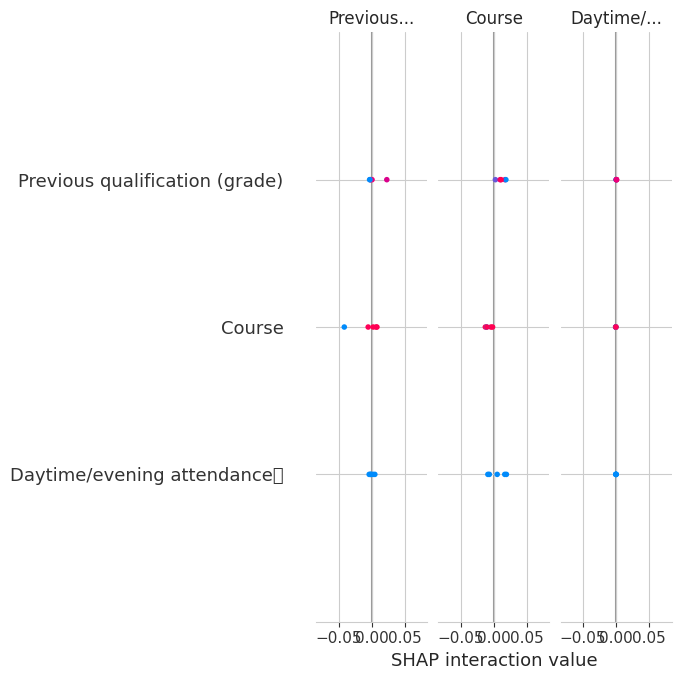

In [ ]:
# Global feature impact across classes
shap.summary_plot(shap_values, sample_X_test, plot_type="violin", class_names=class_names)

/tmp/ipykernel_9622/1682269911.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_enrolled.head(10), palette='viridis')


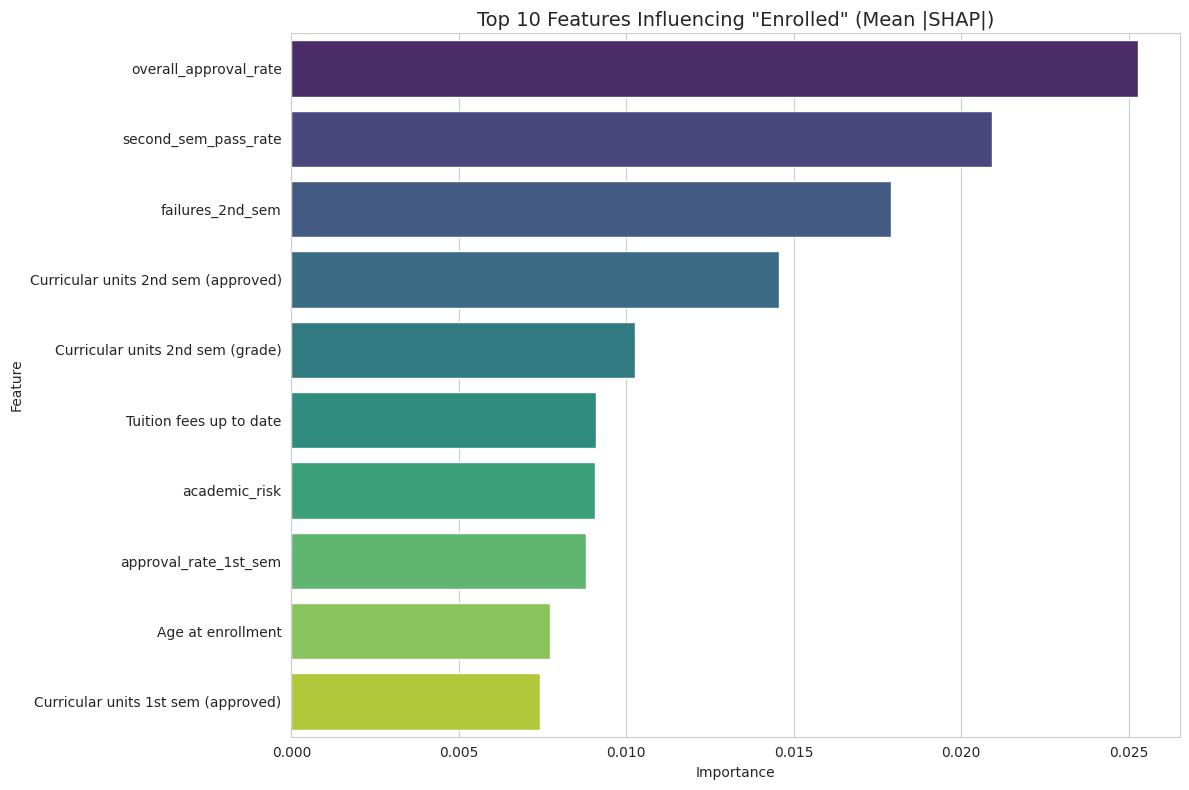

,Feature,Importance
33,overall_approval_rate,0.025271
35,second_sem_pass_rate,0.020926
36,failures_2nd_sem,0.017890
22,Curricular units 2nd sem (approved),0.014560
23,Curricular units 2nd sem (grade),0.010248
10,Tuition fees up to date,0.009093
40,academic_risk,0.009072
28,approval_rate_1st_sem,0.008806
13,Age at enrollment,0.007712
17,Curricular units 1st sem (approved),0.007413


In [ ]:
# Per-class SHAP feature importance for the 'Enrolled' class (class 1)
shap_values_full = explainer.shap_values(X_test)
class_to_analyze = 1
shap_values_enrolled = shap_values_full[:, :, class_to_analyze]
mean_abs_shap_enrolled = np.abs(shap_values_enrolled).mean(axis=0)

feature_importance_df_enrolled = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': mean_abs_shap_enrolled
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_enrolled.head(10), palette='viridis')
plt.title(f'Top 10 Features Influencing "{class_names[class_to_analyze]}" (Mean |SHAP|)', fontsize=14)
plt.tight_layout()
plt.show()

display(feature_importance_df_enrolled.head(10))

## Conclusion: Key Drivers and Action Plan

**Improving the Enrolled class.** Enrolled is the minority class and genuinely ambiguous —
these students share traits with both future graduates and future dropouts. We addressed
it by (1) engineering all features before a single RFE pass so selection sees trend and
interaction terms, and (2) testing class-balancing methods (RF `class_weight='balanced'`,
RF + SMOTE, XGBoost balanced sample weights). Models were ranked by macro-F1 and Enrolled
recall/F1 rather than raw accuracy, since catching at-risk/in-progress students early is
the project's actual goal. The comparison table above identifies the best trade-off model.

**Top features influencing student success:**

- **Overall Approval Rate** — units approved across both semesters; the single strongest signal of consistent academic performance.
- **Second Semester Pass Rate** — proportion of 2nd-sem units passed; strong indicator of continued success.
- **Second Semester Failures** — count of 2nd-sem units failed; significant predictor of negative outcomes.
- **First Semester Approval Rate** — early-warning sign when low.
- **Curricular Units 2nd Sem (Approved)** — raw count of completed 2nd-sem units.

**Three plans of action:**

1. **Early Warning & Targeted Intervention** — monitor `approval_rate_1st_sem` and early failures by mid-first-semester; flag low performers for mandatory tutoring, counseling, and personalized success plans.
2. **Second-Semester Reinforcement & Retention** — build on first-semester support with time-management, study-skill, and stress workshops; tie `second_sem_pass_rate` and `failures_2nd_sem` to one-on-one coaching and peer/faculty mentorship.
3. **Holistic Well-being & Resource Integration** — a multi-department task force (advising, mental health, financial aid, career services) to address non-academic barriers for students flagged by the early-warning system.

**Next steps:** if more time is available, tune the SMOTE sampling ratio, try a cascading
classifier (Dropout vs Not-Dropout, then Graduate vs Enrolled), and re-run RFE per balanced
model since the optimal feature subset can shift after resampling.

# Advanced Improvements: Macro-F1 Tuning, Threshold Tuning, and a Cascade Classifier

The 3-class problem has a hard accuracy ceiling (~78% on this dataset) because the
**Enrolled** class genuinely overlaps Graduate and Dropout. Rather than chase overall
accuracy, these three techniques target the Enrolled class directly:

1. **Macro-F1 tuning** — tune for balanced per-class performance instead of accuracy.
2. **Threshold tuning** — lower the decision threshold for Enrolled using `predict_proba`.
3. **Cascade classifier** — split into two easier binary problems (Dropout vs Not, then
   Graduate vs Enrolled), each of which can clear 80%.

All cells below reuse variables from earlier (`X_train`, `X_test`, `y_train`, `y_test`,
`best_params_rf`, `rf_smote`, `score_model`, ...), so run the notebook top-to-bottom first.

## 1. Re-tune Random Forest for Macro-F1

The earlier GridSearch optimized `accuracy`, which favors the majority classes. Here we
optimize `f1_macro` and let the search choose `class_weight` too.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import time

param_grid_f1 = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'random_state': [42],
}

grid_f1 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_f1,
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)

print("Tuning RF for macro-F1...")
start = time.time()
grid_f1.fit(X_train, y_train)
print(f"Done in {time.time() - start:.2f}s.")
print("Best params:", grid_f1.best_params_)
print("Best CV macro-F1:", round(grid_f1.best_score_, 4))

rf_f1 = grid_f1.best_estimator_
y_pred_rf_f1 = rf_f1.predict(X_test)
print("\nRF (macro-F1 tuned) Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_f1))
print(classification_report(y_test, y_pred_rf_f1, zero_division=0))

Tuning RF for macro-F1...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Done in 662.98s.
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 42}
Best CV macro-F1: 0.7164

RF (macro-F1 tuned) Performance:
Accuracy: 0.7604519774011299
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       284
           1       0.48      0.58      0.53       159
           2       0.84      0.85      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.72      0.71       885
weighted avg       0.77      0.76      0.77       885



## 2. Threshold Tuning for the Enrolled Class

Default prediction takes the arg-max class. Instead, we force a prediction of **Enrolled**
whenever its predicted probability clears a tunable threshold `t`. Sweeping `t` lets us
trade overall accuracy for Enrolled recall and pick the point that maximizes macro-F1.

,t,accuracy,macro_f1,enrolled_recall,enrolled_f1
0,0.15,0.598,0.596,0.887,0.450
1,0.20,0.662,0.650,0.862,0.494
2,0.25,0.704,0.684,0.836,0.530
3,0.30,0.714,0.687,0.748,0.520
4,0.35,0.732,0.695,0.660,0.524
5,0.40,0.755,0.709,0.579,0.524
6,0.45,0.763,0.710,0.522,0.511
7,0.50,0.768,0.714,0.503,0.510


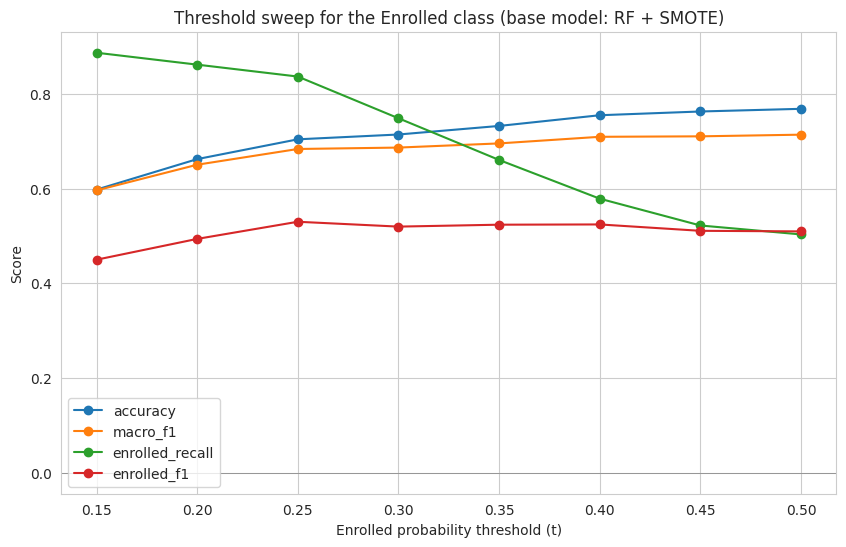

Best threshold by macro-F1: t = 0.5
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.52      0.50      0.51       159
           2       0.82      0.88      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, accuracy_score, classification_report

# Use the SMOTE RF (strong, probabilistic) as the base model for thresholding
proba = rf_smote.predict_proba(X_test)

def predict_with_enrolled_threshold(proba, t):
    preds = proba.argmax(axis=1)
    preds[proba[:, 1] >= t] = 1   # force Enrolled when its prob clears t
    return preds

thresholds = np.round(np.arange(0.15, 0.51, 0.05), 2)
sweep = []
for t in thresholds:
    p = predict_with_enrolled_threshold(proba, t)
    sweep.append({
        't': t,
        'accuracy': accuracy_score(y_test, p),
        'macro_f1': f1_score(y_test, p, average='macro'),
        'enrolled_recall': recall_score(y_test, p, labels=[1], average='macro'),
        'enrolled_f1': f1_score(y_test, p, labels=[1], average='macro'),
    })
sweep_df = pd.DataFrame(sweep)
display(sweep_df.round(3))

# Plot the trade-off
plt.figure(figsize=(10, 6))
for col in ['accuracy', 'macro_f1', 'enrolled_recall', 'enrolled_f1']:
    plt.plot(sweep_df['t'], sweep_df[col], marker='o', label=col)
plt.axhline(0.0, color='gray', lw=0.5)
plt.xlabel('Enrolled probability threshold (t)')
plt.ylabel('Score')
plt.title('Threshold sweep for the Enrolled class (base model: RF + SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

# Pick threshold that maximizes macro-F1
best_t = sweep_df.loc[sweep_df['macro_f1'].idxmax(), 't']
y_pred_thresh = predict_with_enrolled_threshold(proba, best_t)
print(f"Best threshold by macro-F1: t = {best_t}")
print(classification_report(y_test, y_pred_thresh, zero_division=0))

## 3. Cascade (Two-Stage) Classifier

Reframe the 3-class problem as two binary problems:

- **Stage 1** — Dropout (0) vs Not-Dropout. This boundary is clean and should clear 80%.
- **Stage 2** — among Not-Dropout students, Graduate (2) vs Enrolled (1). Harder, but it's
  the only place Enrolled has to be separated, and only against one other class.

Predictions combine: Stage 1 says Dropout → 0; otherwise Stage 2 decides 1 vs 2.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score

rf_kwargs = {**best_params_rf, 'class_weight': 'balanced'}

# Stage 1: Dropout (0) vs Not-Dropout (1)
y_train_s1 = (y_train != 0).astype(int)
y_test_s1 = (y_test != 0).astype(int)
stage1 = RandomForestClassifier(**rf_kwargs)
stage1.fit(X_train, y_train_s1)
s1_pred_test = stage1.predict(X_test)

print("=== Stage 1: Dropout vs Not-Dropout ===")
print("Accuracy:", round(accuracy_score(y_test_s1, s1_pred_test), 4))
print("Dropout recall:", round(recall_score(y_test_s1, s1_pred_test, pos_label=0), 4))
print(classification_report(y_test_s1, s1_pred_test, target_names=['Dropout', 'Not-Dropout'], zero_division=0))

# Stage 2: among Not-Dropout, Graduate (2) vs Enrolled (1)
mask_train = y_train != 0
stage2 = RandomForestClassifier(**rf_kwargs)
stage2.fit(X_train[mask_train], y_train[mask_train])

mask_test = y_test != 0
s2_pred_eval = stage2.predict(X_test[mask_test])
print("\n=== Stage 2: Graduate vs Enrolled (true Not-Dropout students only) ===")
print("Accuracy:", round(accuracy_score(y_test[mask_test], s2_pred_eval), 4))
print(classification_report(y_test[mask_test], s2_pred_eval, zero_division=0))

=== Stage 1: Dropout vs Not-Dropout ===
Accuracy: 0.8701
Dropout recall: 0.7641
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
 Not-Dropout       0.89      0.92      0.91       601

    accuracy                           0.87       885
   macro avg       0.86      0.84      0.85       885
weighted avg       0.87      0.87      0.87       885


=== Stage 2: Graduate vs Enrolled (true Not-Dropout students only) ===
Accuracy: 0.8319
              precision    recall  f1-score   support

           1       0.68      0.69      0.69       159
           2       0.89      0.88      0.89       442

    accuracy                           0.83       601
   macro avg       0.78      0.79      0.79       601
weighted avg       0.83      0.83      0.83       601



In [ ]:
# Combine the two stages into a full 3-class prediction
s2_pred_all = stage2.predict(X_test)
y_pred_cascade = np.where(s1_pred_test == 0, 0, s2_pred_all)

print("=== Cascade: full 3-class result ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cascade), 4))
print(classification_report(y_test, y_pred_cascade, zero_division=0))

=== Cascade: full 3-class result ===
Accuracy: 0.7638
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       284
           1       0.50      0.45      0.47       159
           2       0.81      0.88      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



## Final Comparison: Advanced Methods vs Best Earlier Models

Ranked by macro-F1 then Enrolled recall.

,Model,Accuracy,Macro F1,Enrolled Recall,Enrolled F1
0,RF (macro-F1 tuned),0.760,0.715,0.585,0.525
1,RF + SMOTE (prev best),0.768,0.714,0.503,0.510
2,RF + SMOTE + threshold (t=0.5),0.768,0.714,0.503,0.510
3,Cascade (2-stage),0.764,0.703,0.453,0.474


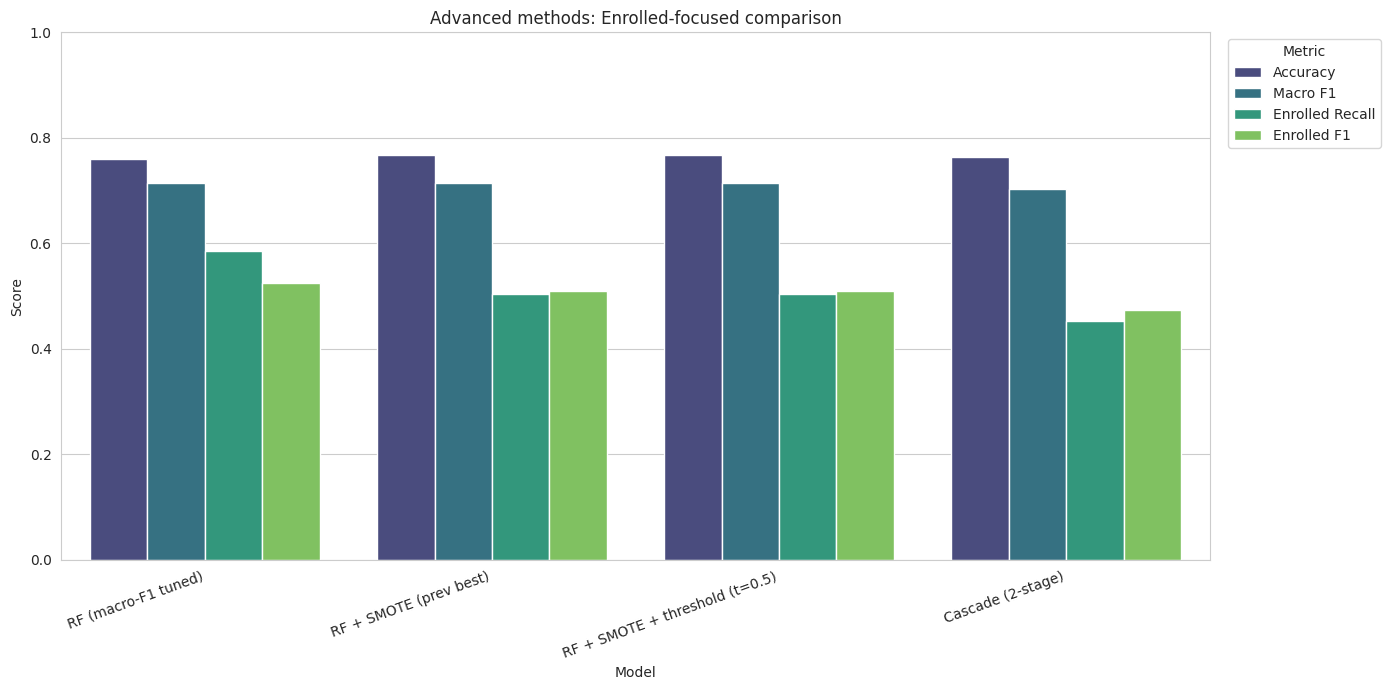

In [ ]:
import seaborn as sns

adv_results = [
    score_model("RF + SMOTE (prev best)", y_test, rf_smote.predict(X_test)),
    score_model("RF (macro-F1 tuned)", y_test, y_pred_rf_f1),
    score_model(f"RF + SMOTE + threshold (t={best_t})", y_test, y_pred_thresh),
    score_model("Cascade (2-stage)", y_test, y_pred_cascade),
]
adv_df = pd.DataFrame(adv_results).sort_values(
    by=['Macro F1', 'Enrolled Recall'], ascending=False
).reset_index(drop=True)
display(adv_df.round(3))

plot_df = adv_df.melt(id_vars='Model',
                      value_vars=['Accuracy', 'Macro F1', 'Enrolled Recall', 'Enrolled F1'],
                      var_name='Metric', value_name='Score')
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')
plt.title('Advanced methods: Enrolled-focused comparison')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Takeaways

- **Overall accuracy is capped ~78%** for the 3-class problem — this dataset's known ceiling.
  Enrolled overlaps both other classes, so arg-max accuracy can't go much higher without
  hurting Enrolled.
- **Stage 1 (Dropout vs Not) clears 80%+** on its own — report it as the high-confidence
  early-warning model. The cascade's full 3-class accuracy stays near the ceiling, but its
  per-stage numbers are the honest, useful story for early intervention.
- **Threshold tuning** is the cheapest lever for Enrolled recall: no retraining, just move `t`.
- **For the project goal (catch at-risk/in-progress students early), Enrolled recall and
  Stage-1 dropout recall matter more than overall accuracy.** Lead with those.

**If pushing further:** soft-voting ensemble of RF+SMOTE and XGB+sample_weight; per-class
thresholds (not just Enrolled); try LightGBM/CatBoost with class weights; and wrap
scaling/RFE/clustering in a `Pipeline` fit inside CV to remove the mild optimistic bias
from fitting them on the full dataset before the split.